In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson


In [19]:
data=pd.read_csv("velib_horaire.csv")
data["Departure_Time"]= pd.to_datetime(data["Departure_Time"])
data = data.sort_values("Departure_Time").set_index("Departure_Time")

print(data.head())


                     duree_moyenne_sec  proportion_velos_electriques  \
Departure_Time                                                         
2024-05-01 00:00:00        1066.162766                      0.588298   
2024-05-01 01:00:00        1190.689723                      0.570299   
2024-05-01 02:00:00        1186.409469                      0.543506   
2024-05-01 03:00:00        1172.889674                      0.562500   
2024-05-01 04:00:00        1112.989264                      0.565184   

                     nombre_trajets  
Departure_Time                       
2024-05-01 00:00:00            4700  
2024-05-01 01:00:00            3542  
2024-05-01 02:00:00            3126  
2024-05-01 03:00:00            1840  
2024-05-01 04:00:00            1304  


In [ ]:
Y=data["nombre_trajets"]

print("Moyenne :", Y.mean())
print("Variance :", Y.var())
print("Écart-type :", Y.std())

Moyenne : 6016.092361111111
Variance : 17630569.02898957
Écart-type : 4198.877115252311


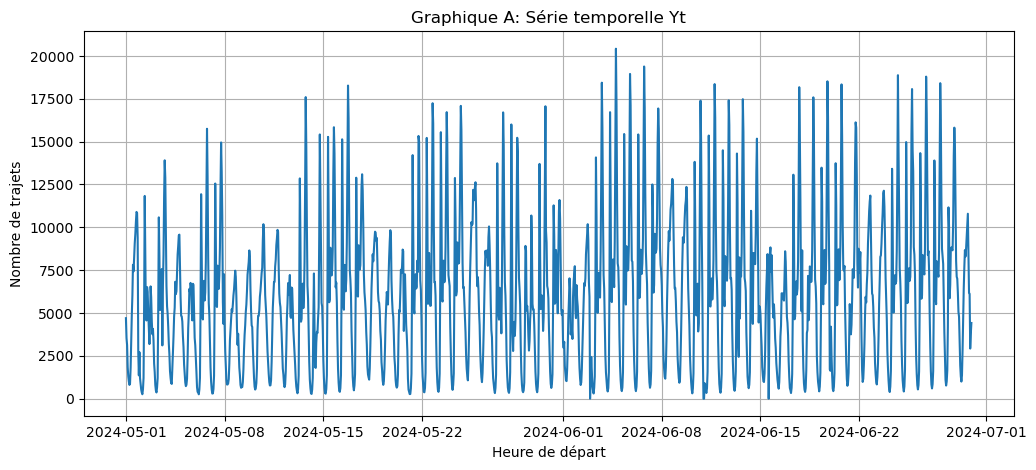

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(Y)
plt.title("Graphique A: Série temporelle Yt")
plt.xlabel("Heure de départ")
plt.ylabel("Nombre de trajets")
plt.grid(True)
plt.show()

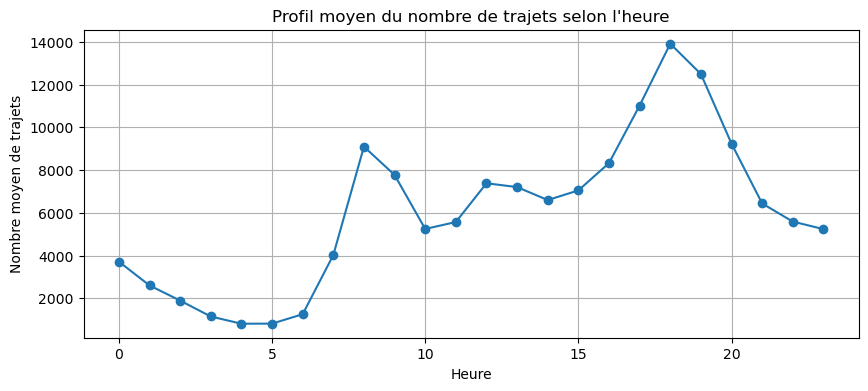

In [25]:
profil_horaire = Y.groupby(Y.index.hour).mean()

plt.figure(figsize=(10,4))
plt.plot(profil_horaire.index, profil_horaire.values, marker="o")
plt.title("Profil moyen du nombre de trajets selon l'heure")
plt.xlabel("Heure")
plt.ylabel("Nombre moyen de trajets")
plt.grid(True)
plt.show()

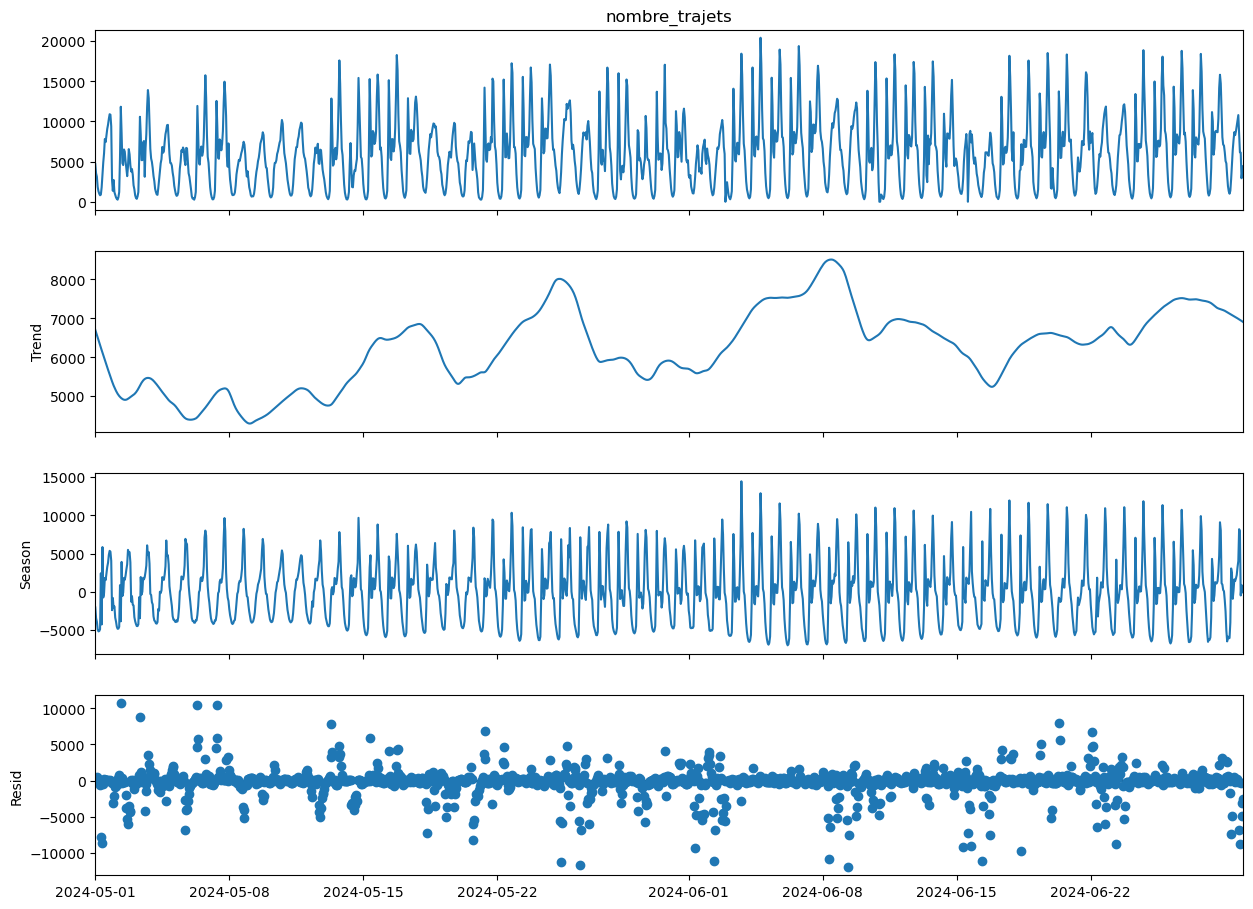

In [30]:
stl = STL(Y, period=24, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14,10)
plt.show()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

In [16]:

result = adfuller(Y, autolag="AIC")

print("Résultats du test ADF sur Yt = nombre_trajets")
print(f"Statistique ADF : {result[0]:.6f}")
print(f"p-value         : {result[1]:.6f}")
print(f"Nombre de retards utilisés : {result[2]}")
print(f"Nombre d'observations      : {result[3]}")
print("Valeurs critiques :")
for key, value in result[4].items():
    print(f"   {key} : {value:.6f}")

# Conclusion automatique
if result[1] < 0.05:
    print("\nConclusion : on rejette H0.")
    print("La série Yt peut être considérée comme stationnaire.")
else:
    print("\nConclusion : on ne rejette pas H0.")
    print("La série Yt n'est pas stationnaire.")

Résultats du test ADF sur Yt = nombre_trajets
Statistique ADF : -3.906894
p-value         : 0.001985
Nombre de retards utilisés : 24
Nombre d'observations      : 1415
Valeurs critiques :
   1% : -3.434980
   5% : -2.863585
   10% : -2.567859

Conclusion : on rejette H0.
La série Yt peut être considérée comme stationnaire.


Le test n'a pas repéré les composantes saisonnières de la série.
Le processus semble contenir une composante saisonniere de periode 24h et une composante saisonière de 7 jours. C'est ce que l'on peut déduire de ce que l'on sait sur les vélib et du graphique A.

<Figure size 1200x400 with 0 Axes>

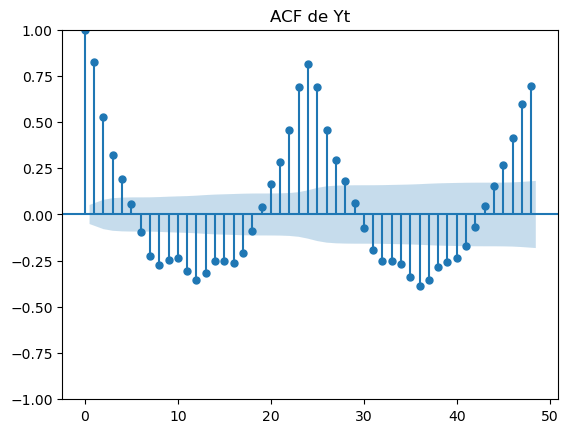

<Figure size 1200x400 with 0 Axes>

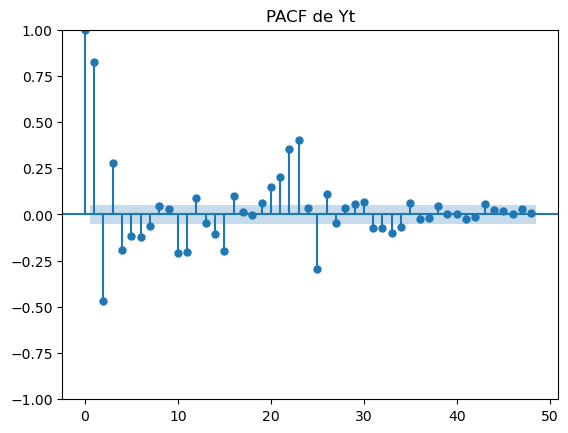

In [17]:
plt.figure(figsize=(12, 4))
plot_acf(Y, lags=48)
plt.title("ACF de Yt")
plt.show()

plt.figure(figsize=(12, 4))
plot_pacf(Y, lags=48, method="ywm")
plt.title("PACF de Yt")
plt.show()